# ST-GCN: Spatial Temporal Graph Convolutional Network
Para el modelado de las secuencias, hemos optado por una arquitectura ST-GCN (Spatio-Temporal Graph Convolutional Network), diseñada específicamente para datos estructurados en forma de esqueleto. A diferencia de las redes recurrentes tradicionales, este enfoque interpreta los datos de salida de MediaPipe no como un vector plano, sino como un grafo donde los $V=33$ nodos representan las articulaciones y las aristas sus conexiones biomecánicas naturales.

Nuestra implementación se basa en una pila de bloques modulares (`STGCN_Block`). Cada uno de estos bloques descompone el aprendizaje de características en dos fases secuenciales:

1. Filtrado Espacial (GCN):  Aplica convoluciones sobre el grafo para agregar información de las articulaciones vecinas, utilizando una matriz de adyacencia particionada que captura la estructura espacial del cuerpo.
2. Filtrado Temporal (TCN): Emplea convoluciones 2D estándar sobre la dimensión temporal para aprender la dinámica del movimiento a lo largo de los frames.

Un aspecto crítico de nuestra implementación `STGCN_Model` es la gestión de secuencias de longitud variable. Antes de procesar los datos, transformamos el tensor de entrada a la forma $(N, C, T, V)$ requerida por la red. Finalmente, para la clasificación, hemos diseñado una capa de Global Average Pooling con enmascaramiento (masking). Este mecanismo permite promediar las características extraídas ignorando explícitamente los valores de zero-padding, asegurando que la predicción final se base únicamente en los instantes reales del ejercicio.



In [35]:
# Librerías necesarias
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

## Implementación de la arquitectura

### Definición de la Capa de Convolución Espacial (GCN)

La clase SpatialGraphConv es el componente encargado de que cada articulación (nodo) integre la información de sus vecinas directas para comprender la postura espacial en un instante dado.

El diseño original de ST-GCN introduce el concepto de estrategia de particionamiento espacial, controlado por el parámetro $K$. La teoría detrás de este parámetro es dividir a los vecinos de un nodo en $K$ subgrupos distintos según su rol biomecánico (por ejemplo, distinguir entre el nodo mismo, los vecinos más cercanos al centro de gravedad y los más alejados). Esto permite que la red aprenda un conjunto de pesos diferente para cada tipo de vecino, otorgando mayor flexibilidad al modelo.

Aunque nuestro código para SpatialGraphConv es genérico y está preparado para soportar múltiples particiones iterando $K$ veces y aplicando $K$ capas convolucionales distintas, **en este trabajo hemos optado por la configuración más sencilla posible**: una estrategia de partición única ($K=1$).

Esto implica que, en nuestra práctica:

1. Utilizamos una única matriz de adyacencia normalizada para definir las conexiones.

2. Todos los vecinos se tratan de forma uniforme; la red no distingue explícitamente entre diferentes tipos de conexiones espaciales.

3. Se utiliza un único conjunto de pesos entrenables (una sola capa convolucional de 1x1) para procesar la información agregada de todos los vecinos.

Esta decisión simplifica el modelo y reduce el número de parámetros, lo cual es adecuado dado el tamaño limitado de nuestro conjunto de datos.

In [36]:
class SpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A_partitions):
        super().__init__()
        self.K = len(A_partitions)  # Número de particiones
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=1) 
            for _ in range(self.K)
        ])
        self.register_buffer('A', A_partitions) # A_partitions es la matriz A normalizada

    def forward(self, x):
        # x tiene forma (N, C_in, T, V), donde V=33 (keypoints)
        output = None
        for k in range(self.K):
            # 1. Multiplicación del feature map por la matriz A_k
            # torch.einsum realiza (N, C_in, T, V) @ (V, V) -> (N, C_in, T, V)
            # donde V x V es la matriz A_k (aplicando la adyacencia)
            x_neighbor = torch.einsum('nctv,vw->nctw', (x, self.A[k]))
            
            # 2. Convolución 1x1 (aplicando W_k)
            z = self.convs[k](x_neighbor) 

            # 3. Sumar los resultados de las K particiones
            output = z if output is None else output + z
        
        return output

El método `forward` procesa el tensor de entrada $\mathbf{x}$ de dimensiones $(N, C_{input}, T, V)$, donde:
- $N$ es el tamaño del bactch.
- $C_{input}$ es el número de canales de entrada de cada nodo es decir. Es decir, hace referencia a las coordenadas (2 para x, y).
- $T$ es la dimensión temporal (el número de frames de la secuencia).
- $V$ es el número de vértices (nodos) del grafo espacial.

Aunque en nuestro caso el bucle `for k in range(self.K)` se ejecuta una sola vez, el mecanismo general consta de tres pasos fundamentales para cada partición:

1. **Agregación de Vecinos (Difusión)**: 
Utilizamos la operación eficiente `torch.einsum('nctv,vw->nctw', (x, self.A[k]))`. Esta línea realiza una multiplicación tensorial entre las características de los nodos y la matriz de adyacencia normalizada de la partición actual ($\mathbf{A}_k$). Físicamente, esto "mezcla" la información de cada articulación con la de sus vecinas conectadas según la topología del grafo, resultando en el tensor intermedio x_neighbor.

2. **Transformación de Características (Pesos)**:
A continuación, aplicamos una convolución 2D de 1x1 (`self.convs[k]`). En este contexto, una convolución de 1x1 actúa funcionalmente como una proyección lineal que transforma la dimensión de los canales de entrada ($C_{input}$) a la de salida ($C_{out}$). Es aquí donde residen los pesos entrenables ($\mathbf{W}_k$) que la red ajusta durante el aprendizaje.

3. **Acumulación**: Finalmente, los resultados transformados de todas las particiones se suman para obtener la representación espacial final. (En nuestro caso con $K=1$, el resultado es simplemente la salida de la única rama procesada).

### Definición de la Capa de Convolución Temporal (TCN)

Tras la agregación espacial realizada por la GCN, el módulo TCN (Temporal Convolutional Network) es el encargado de modelar la evolución dinámica de las características a lo largo del tiempo.

Nuestra implementación utiliza una pila de capas dentro de un bloque `nn.Sequential`, cuyo núcleo es una convolución 2D estándar configurada específicamente para el procesamiento temporal:

- **Núcleo Espacio-Temporal**: Definimos un tamaño de núcleo de (`T_kernel, 1`). La dimensión espacial de 1 es crucial, ya que asegura que la operación se aplique independientemente a la línea de tiempo de cada articulación, sin mezclar información entre vértices distintos (tarea que ya realizó la GCN previa).

- **Preservación Temporal**: Aplicamos padding en la dimensión temporal (`T_kernel // 2`) para garantizar que el tensor de salida mantenga la misma longitud de secuencia $T$ que el de entrada.

El bloque se completa con capas de Batch Normalization para la estabilidad del entrenamiento y Dropout como mecanismo de regularización esencial para mitigar el sobreajuste.

In [37]:
class STGCN_Block(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, A_partitions, dropout=0.5):
        super().__init__()
        
        T_kernel, V_kernel = kernel_size
        
        # 1. GCN (Espacial) 
        # Se encarga de transformar la dimensión de canales (in -> out)
        self.gcn = SpatialGraphConv(in_channels, out_channels, A_partitions)
        
        # 2. TCN (Temporal) 
        # Mantiene los canales (out -> out)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels), # BN antes o después de ReLU (aquí estilo Pre-activation para TCN)
            nn.ReLU(),
            nn.Conv2d(
                out_channels, 
                out_channels, 
                kernel_size=(T_kernel, 1), 
                padding=(T_kernel // 2, 0)
            ),
            nn.BatchNorm2d(out_channels), # Normalizar salida temporal
            nn.Dropout(dropout) # Regularización vital
        )
        
        # 3. Residual (Skip Connection)
        # Si los canales cambian, usamos una conv 1x1 para adaptar
        if in_channels != out_channels:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (N, C_in, T, V)

        # A. Rama Residual
        res = self.residual(x)

        # B. Rama Principal (GCN -> TCN)
        
        # 1. Espacial
        x_gcn = self.gcn(x) 
        
        # 2. Temporal (incluye BN, ReLU y Dropout internamente)
        x_tcn = self.tcn(x_gcn)

        # C. Suma y Activación Final
        return self.relu(x_tcn + res)

El método forward orquesta el procesamiento conjunto de la información espacial y temporal dentro de un único bloque ST-GCN. Este bloque implementa una arquitectura residual clásica, donde el tensor de entrada $\mathbf{x}$ de dimensiones $(N, C_{in}, T, V)$ se procesa a través de dos ramas paralelas que posteriormente se fusionan.

El flujo de operaciones consta de tres etapas:

1. **Rama Residual (Shortcut)**: Se calcula una conexión directa (`self.residual(x)`). El objetivo de esta rama es facilitar el flujo de gradientes durante el entrenamiento de redes profundas.
    * Si el número de canales de entrada ($C_{in}$) difiere del de salida ($C_{out}$), esta rama aplica una convolución de $1 \times 1$ para proyectar y adaptar las dimensiones.
En caso contrario, actúa como una simple conexión de identidad, pasando la entrada sin modificaciones.
    * En caso contrario, actúa como una simple conexión de identidad, pasando la entrada sin modificaciones.

2. **Rama Principal** *(Espacio-Temporal)*: La entrada se procesa secuencialmente a través de los módulos especializados:
    * **Filtrado Espacial**: Primero, `self.gcn(x)` aplica la convolución en grafos para agregar información de las articulaciones vecinas en cada instante de tiempo.
    * **Filtrado Temporal**: La salida de la GCN pasa a `self.tcn(...)`, que modela la dinámica temporal de cada articulación de forma independiente.

3. **Fusión y Activación**: Finalmente, las salidas de la rama principal y la rama residual se suman elemento a elemento. El resultado pasa por una función de activación ReLU para introducir no linealidad antes de ser enviado al siguiente bloque de la red.

### Definición de la arquitectura completa

La clase `STGCN_Model` orquesta el funcionamiento completo de la red. Su función principal es transformar las secuencias de coordenadas crudas en una predicción de clase, integrando los bloques de extracción de características (`STGCN_Block`) con mecanismos específicos de preprocesamiento y clasificación.

Nuestra implementación aborda tres aspectos clave de la arquitectura:

1. **Construcción del Backbone**:
En el constructor, definimos la estructura profunda de la red. Dado que MediaPipe nos devuelve 33 puntos clave con coordenadas $(x, y)$, configuramos la entrada con $V=33$ y $C=2$.
El núcleo de extracción de características se compone de una pila secuencial de bloques `STGCN_Block`. Hemos diseñado la red para aumentar progresivamente la profundidad de los canales (de 64 a 128), lo que permite al modelo aprender patrones de movimiento cada vez más complejos y abstractos a medida que la información fluye por las capas.

2. **Adaptación de Tensores** (`_prep_input`):
PyTorch requiere un formato específico para realizar convoluciones, pero nuestros datos de entrada llegan como vectores planos de forma $(N, T, 66)$.
Para solucionar esto, implementamos el método auxiliar `_prep_input`, que reestructura los datos geométricamente. Primero separamos las coordenadas $x, y$ y luego permutamos las dimensiones para obtener el tensor $(N, C, T, V)$ que requieren las capas convolucionales, recuperando así la estructura espacial necesaria para el procesamiento.

3. **Estrategia de Pooling con Enmascaramiento** (*Masking*): Este es el componente más crítico de nuestra implementación para manejar la naturaleza variable de los vídeos. Como entrenamos por lotes, las secuencias más cortas se rellenan con ceros (zero-padding) para igualar al vídeo más largo. Si aplicáramos un promedio global estándar, estos ceros "contaminarían" el resultado.

    Nuestra implementación personalizada de _pool_and_classify resuelve esto en tres fases:

    * **Generación de la Máscara** (`_create_mask()`): Primero, generamos un tensor booleano (`mask`) de dimensiones $(N, T)$ que indica qué frames son válidos. La máscara se construye examinando la entrada original (`x_in`): un frame se considera relleno si todos sus valores son cero.
    * **Anulación del Padding y Suma Enmascarada**: Una vez que el stack ST-GCN ha generado el tensor de características final $\mathbf{x}$ (forma $(N, C_{out}, T, V)$), utilizamos la máscara para anular el relleno:
        1. **Ajuste Dimensional**: Extendemos la máscara a cuatro dimensiones (`mask_4d` $\rightarrow (N, 1, T, 1)$) para que sea compatible con $\mathbf{x}$ a través de la regla de broadcasting de PyTorch.
        2. **Anulación**: Multiplicamos el tensor de características por la máscara (`x_masked = x * mask_4d`). Dado que la máscara contiene $0$ para el relleno y $1$ para los datos reales, esta multiplicación establece todos los valores de las características del padding a cero.
        3. **Suma**: Calculamos la suma de la señal real (`sum_features = x_masked.sum(dim=(2, 3))`). Al haber anulado previamente el padding, esta suma nos proporciona el numerador del promedio, conteniendo exclusivamente la contribución de los frames válidos. El resultado tiene la forma $(N, C_{out})$.

    * **Normalización y Clasificación**: El paso final consiste en convertir la suma en un promedio válido.
        1. **Cálculo del Denominador**: Determinamos el número total de puntos válidos (`total_valid_nodes`) contando los frames reales en la máscara y multiplicándolos por el número fijo de vértices ($V=33$).
        2. **Promedio Válido**: Dividimos la `sum_features` (el numerador) por `total_valid_nodes` (el denominador). Esto genera el vector final de características `x_pooled` de forma $(N, C_{out})$.
        3. **Clasificación**: El vector `x_pooled` (el resumen promedio del movimiento) se introduce en la capa lineal (`self.classifier`) para obtener la probabilidad final de las clases.

![Arquitectura ST-GCN](../img/ST-GCN-arquitectura.png)

In [38]:
class STGCN_Model(nn.Module):
    def __init__(self, num_classes, A_partitions):
        super().__init__()
        
        # Parámetros fijos para MediaPipe Pose (x, y)
        self.C = 2 # Coordenadas x, y
        self.V = 33 # Keypoints/Nodos
        
        # El resto de la arquitectura STGCN sigue igual
        # Asumimos que el primer bloque STGCN recibe 2 canales (x, y)
        self.st_gcn_stack = nn.Sequential(
            STGCN_Block(self.C, 64, (9, 1), A_partitions),
            STGCN_Block(64, 64, (9, 1), A_partitions),
            STGCN_Block(64, 128, (9, 1), A_partitions),
        )

        self.out_channels = 128 
        self.classifier = nn.Linear(self.out_channels, num_classes)


    # MÉTODOS PRIVADOS PARA DESACOPLAR FUNCIONALIDADES
    def _create_mask(self, x_in):
        """ Genera la máscara (N, T) a partir de los ceros de padding. """
        sum_features = torch.sum(x_in, dim=2) 
        mask = (sum_features != 0)
        return mask.float()
    
    def _prep_input(self, x_in):
        """ Realiza el Reshape y Permute para preparar el tensor para ST-GCN. """
        N, T, F = x_in.shape
        
        # Reshape: (N, T, 66) -> (N, T, C, V)
        x = x_in.reshape(N, T, self.C, self.V) 
        
        # Permute: (N, T, C, V) -> (N, C, T, V)
        x = x.permute(0, 2, 1, 3) 
        return x

    def _pool_and_classify(self, x, mask):
        """ Aplica Global Average Pooling con masking y realiza la clasificación final. """
        
        # Preparamos la máscara para broadcasting (N, 1, T, 1)
        mask_4d = mask.unsqueeze(1).unsqueeze(3) 
        
        # Aplicamos la máscara y sumamos
        # Multiplicamos la salida final por la máscara para anular el padding
        x_masked = x * mask_4d
        sum_features = x_masked.sum(dim=(2, 3)) # Suma sobre T y V -> (N, C_out)

        # 3. Normalizar (Contar Nodos Válidos)
        valid_frames_count = mask.sum(dim=1) # Suma sobre T -> Forma (N,)
        total_valid_nodes = (valid_frames_count * self.V).unsqueeze(1) # Forma (N, 1)
        
        # 4. Calcular el Promedio Válido (Evitando división por cero)
        x_pooled = sum_features / (total_valid_nodes + 1e-8) 

        # 5. Clasificar
        return self.classifier(x_pooled)

    # FUNCIÓN FORWARD (LIMPIA)
    def forward(self, x_in):
        # x_in tiene la forma (N, T, 66)

        # 1. Preprocesamiento: Generar la máscara y reestructurar el tensor
        mask = self._create_mask(x_in)
        x = self._prep_input(x_in)

        # 2. Procesamiento Núcleo ST-GCN
        # NOTA: Los bloques TCN/GCN dentro del Sequential NO necesitan el masking
        # ya que la pérdida por el padding se corrige en el pooling final.
        x = self.st_gcn_stack(x)
        
        # 3. Post-procesamiento: Pooling y Clasificación
        return self._pool_and_classify(x, mask)

## Preparación y Formato de los Datos.
La arquitectura ST-GCN exige que los datos se estructuren en un formato tensorial específico para que la convolución sobre grafos funcione correctamente. Este proceso implica no solo el reordenamiento de las coordenadas, sino también la definición explícita de la topología del esqueleto a través de la matriz de adyacencia $\mathbf{A}$.

### Construcción de la matriz de adyacencia
La matriz de adyacencia ($\mathbf{A}$) es fundamental, ya que codifica las conexiones físicas de nuestro esqueleto. Esta matriz es la entrada clave para la capa SpatialGraphConv.

Nuestro proceso para obtener la matriz $\mathbf{A}$ adecuada para el modelo sigue dos pasos esenciales:

1. **Construcción de la Matriz Bruta (A_ADJ_RAW)**: Mediante la función `build_mediapipe_adjacency_matrix()`, definimos manualmente las conexiones óseas (EDGES) entre los 33 keypoints de MediaPipe. Esta lista de pares genera una matriz binaria $33 \times 33$ que refleja la topología física.

$$A_{ij} = \begin{cases} 1 & \text{si hay un borde entre } i \text{ y } j \\ 0 & \text{en caso contrario} \end{cases}$$

In [39]:
import numpy as np

def build_mediapipe_adjacency_matrix(num_keypoints=33):
    """
    Construye la matriz de adyacencia (A_ADJ) para los 33 keypoints de MediaPipe Pose.
    """
    
    # Esta lista de conexiones define la estructura de las extremidades y el tronco.
    EDGES = [
        # Cabeza y Tronco Central
        (0, 1), (1, 2), (2, 3), (3, 7), (4, 5), (5, 6), (6, 8), # Ojos, Nariz, Orejas
        (9, 10), (11, 12), (23, 24), # Boca, Hombros, Caderas
        
        # Conexiones Hombro/Cadera/Tronco
        (11, 23), (12, 24), (11, 12), (23, 24), # Tronco (Hombro-Cadera, Hombro-Hombro, Cadera-Cadera)

        # Brazo Izquierdo
        (11, 13), (13, 15), (15, 17), (17, 19), (19, 21), # Hombro I -> Muñeca I -> Dedos
        
        # Brazo Derecho
        (12, 14), (14, 16), (16, 18), (18, 20), (20, 22), # Hombro D -> Muñeca D -> Dedos
        
        # Pierna Izquierda
        (23, 25), (25, 27), (27, 29), (29, 31), # Cadera I -> Pie I
        
        # Pierna Derecha
        (24, 26), (26, 28), (28, 30), (30, 32), # Cadera D -> Pie D
        
        # Conexión cruzada entre lados (muñecas)
        (15, 17), (16, 18),
    ]

    # Inicializamos la matriz de adyacencia (33x33) con ceros
    A_ADJ = np.zeros((num_keypoints, num_keypoints), dtype=np.float32)

    # Llenamos la matriz con las conexiones 
    for i, j in EDGES:
        # Ponemos 1 para la conexión (i -> j) y (j -> i) (grafo no dirigido)
        if 0 <= i < num_keypoints and 0 <= j < num_keypoints:
            A_ADJ[i, j] = 1.0
            A_ADJ[j, i] = 1.0

    return A_ADJ

# Generamos la matriz de adyacencia
A_ADJ_RAW = build_mediapipe_adjacency_matrix()

print(f"La matriz de adyacencia RAW tiene forma: {A_ADJ_RAW.shape}")

La matriz de adyacencia RAW tiene forma: (33, 33)


2. **Normalización Simétrica** (`A_NORM_TENSOR`): Para que la operación de convolución en grafos sea estable y no altere la escala de las características, la matriz bruta debe ser normalizada. Aplicamos la normalización simétrica comúnmente utilizada en la literatura de GCN:

$$\mathbf{A}_{\text{norm}} = \mathbf{D}^{-1/2} (\mathbf{A} + \mathbf{I}) \mathbf{D}^{-1/2}$$

* Donde $\mathbf{I}$ añade el lazo propio (self-loop) para que cada nodo se considere su propio vecino, y $\mathbf{D}$ es la matriz de grados.

### Matriz de particiones para ST-GCN

In [40]:
def normalize_adjacency(A_adj):
    """
    Calcula la matriz de adyacencia normalizada simétrica (D^-1/2 * A' * D^-1/2).
    """
    # 1. Añadimos el lazo propio (self-loop): A' = A + I
    A_prime = A_adj + np.eye(A_adj.shape[0])
    
    # 2. Calculamos la matriz de grado D (suma de filas)
    D = np.sum(A_prime, axis=1)
    
    # 3. Calculamos D^-1/2
    D_half_norm = np.diag(D ** (-0.5))
    
    # 4. Calculamos A_norm = D^-1/2 * A' * D^-1/2
    A_norm = D_half_norm @ A_prime @ D_half_norm
    
    # Devolvemos como tensor PyTorch (asumiendo que STGCN_Model usa K=1 partición)
    return torch.tensor(A_norm, dtype=torch.float32)

# La matriz A normalizada para un modelo K=1
A_NORM_TENSOR = normalize_adjacency(A_ADJ_RAW)

# Para usar en el modelo STGCN_Model_Adapted (con K=1), pasaríamos un tensor de forma (1, V, V)
A_PARTITIONS_K1 = A_NORM_TENSOR.unsqueeze(0) 

print(f"\nLa matriz normalizada (para K=1) tiene forma: {A_PARTITIONS_K1.shape}")


La matriz normalizada (para K=1) tiene forma: torch.Size([1, 33, 33])


In [41]:
# !git clone https://github.com/victorlopez-ds/push-up-video-classification.git

In [42]:
# %cd push-up-video-classification/

## Experimentos

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import numpy as np
import copy 

# Definimos el dispositivo de ejecución
# Si CUDA (NVIDIA GPU) está disponible, usa la GPU; si no, usa la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# model.to(device)

Usando dispositivo: cuda


In [44]:
# 1. FUNCIÓN DE ENTRENAMIENTO (UNA ÉPOCA)
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta el paso de entrenamiento para una sola época."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
        
    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    return avg_loss, avg_acc


# 2. FUNCIÓN DE VALIDACIÓN (UNA ÉPOCA)
def validate_one_epoch(model, loader, criterion, device):
    """Ejecuta la evaluación sin calcular gradientes."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Listas para guardar predicciones (útil para el paso final del fold)
    preds_list = []
    labels_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            # Guardamos predicciones por si es la última pasada
            preds_list.extend(predicted.cpu().numpy())
            labels_list.extend(y_batch.cpu().numpy())
            
    avg_loss = running_loss / len(loader.dataset)
    avg_acc = correct / total
    
    return avg_loss, avg_acc, preds_list, labels_list


# 3. ENTRENAMIENTO DE UN SOLO FOLD
def train_single_fold(model, train_loader, val_loader, epochs, lr, patience, device):
    """Entrena un modelo desde cero para un fold específico con Early Stopping."""
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    
    # Variables de Early Stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    
    for epoch in range(epochs):
        # 1. Entrenar
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        # 2. Validar
        val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)
        
        # 3. Guardamos historia
        history['loss'].append(train_loss)
        history['acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # 4. Lógica Early Stopping
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_weights = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"    -> Early stopping en época {epoch+1}")
                    break
    
    # 5. Restauramos el mejor modelo y hacemos inferencia final
    if best_weights:
        model.load_state_dict(best_weights)
    
    # Hacemos una última pasada de validación con el MEJOR modelo para sacar las predicciones
    final_val_loss, final_val_acc, final_preds, final_labels = validate_one_epoch(model, val_loader, criterion, device)
    
    return final_val_acc, history, final_preds, final_labels


# 4. FUNCIÓN PRINCIPAL (EJECUCIÓN DE UN EXPERIMENTO K-FOLD)
def run_kfold_experiment_pytorch(model_class, model_params, X_full, y_full, 
                                 epochs, batch_size, lr=0.001, n_splits=5, patience=None, device='cpu'):
    
    # Aseguramos los tipos numpy
    if isinstance(X_full, torch.Tensor): X_full = X_full.cpu().numpy()
    if isinstance(y_full, torch.Tensor): y_full = y_full.cpu().numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Acumuladores Globales
    fold_accuracies = []
    fold_histories = []
    global_y_true = []
    global_y_pred = []
    
    print(f"** Iniciando K-Fold Modular ({n_splits} splits) en {device}...")
    print("===" * 20)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_full)):
        print(f"\n🔄 Pliegue {fold_idx + 1}/{n_splits}")
        
        # A. Preparamos los Tensores y Loaders
        X_train_t = torch.tensor(X_full[train_index], dtype=torch.float32)
        y_train_t = torch.tensor(y_full[train_index], dtype=torch.long)
        X_val_t = torch.tensor(X_full[val_index], dtype=torch.float32)
        y_val_t = torch.tensor(y_full[val_index], dtype=torch.long)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
        
        # B. Inicializamos Modelo
        model = model_class(**model_params).to(device)
        
        # C. Delegamos el trabajo sucio a la función 'train_single_fold'
        val_acc, history, fold_preds, fold_labels = train_single_fold(
            model, train_loader, val_loader, epochs, lr, patience, device
        )

        # D. Recolectamos resultados
        print(f"    + Fin Fold {fold_idx+1}. Mejor Acc Val: {val_acc:.4f}")
        
        fold_accuracies.append(val_acc)
        fold_histories.append(history)
        global_y_true.extend(fold_labels)
        global_y_pred.extend(fold_preds)

    # E. Resultados Finales
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    
    print("===" * 20)
    print(f"📊 Resultados K-Fold:")
    print(f"| Accuracy Medio: {mean_acc:.4f} (+/- {std_acc:.4f})")
    
    return mean_acc, std_acc, fold_histories, np.array(global_y_true), np.array(global_y_pred)

In [45]:
import matplotlib.pyplot as plt

def plot_kfold_history_pytorch(fold_histories, title='Métricas K-Fold ST-GCN'):
    """Grafica Loss y Accuracy promedio con sombra de desviación estándar."""
    
    if not fold_histories:
        print("Error: No hay historias para graficar.")
        return

    # Encontramos la longitud mínima (por si hubo Early Stopping en tiempos distintos)
    # Cortamos todas las gráficas a la longitud del entrenamiento más corto
    min_epochs = min(len(h['loss']) for h in fold_histories)
    
    print(f"Graficando las primeras {min_epochs} épocas comunes...")

    # Creamos arrays para promedios
    metrics = ['loss', 'val_loss', 'acc', 'val_acc']
    data = {m: np.zeros((len(fold_histories), min_epochs)) for m in metrics}

    for i, history in enumerate(fold_histories):
        for m in metrics:
            data[m][i, :] = history[m][:min_epochs]

    # Calculamos medias y desviaciones
    means = {m: np.mean(data[m], axis=0) for m in metrics}
    stds = {m: np.std(data[m], axis=0) for m in metrics}
    
    epochs_range = range(1, min_epochs + 1)

    # --- PLOT 1: LOSS ---
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Train Loss
    plt.plot(epochs_range, means['loss'], label='Train Loss', color='blue')
    plt.fill_between(epochs_range, means['loss'] - stds['loss'], means['loss'] + stds['loss'], color='blue', alpha=0.1)
    # Val Loss
    plt.plot(epochs_range, means['val_loss'], label='Val Loss', color='red')
    plt.fill_between(epochs_range, means['val_loss'] - stds['val_loss'], means['val_loss'] + stds['val_loss'], color='red', alpha=0.1)
    
    plt.title(f'{title} - Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- PLOT 2: ACCURACY ---
    plt.subplot(1, 2, 2)
    # Train Acc
    plt.plot(epochs_range, means['acc'], label='Train Acc', color='blue')
    plt.fill_between(epochs_range, means['acc'] - stds['acc'], means['acc'] + stds['acc'], color='blue', alpha=0.1)
    # Val Acc
    plt.plot(epochs_range, means['val_acc'], label='Val Acc', color='green')
    plt.fill_between(epochs_range, means['val_acc'] - stds['val_acc'], means['val_acc'] + stds['val_acc'], color='green', alpha=0.1)
    
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

### EXP-ST-GCN-01
Evaluación del modelo con K-Fold

In [46]:
# Cargamos los numpy arrays guardados
X_correct = np.load('./Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect = np.load('./Data/Processed/wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

# Convertir a tensores de PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

original_index = np.arange(X_tensor.shape[0])

** Iniciando K-Fold Modular (5 splits) en cuda...

🔄 Pliegue 1/5
    -> Early stopping en época 55
    + Fin Fold 1. Mejor Acc Val: 0.8000

🔄 Pliegue 2/5
    + Fin Fold 2. Mejor Acc Val: 0.9000

🔄 Pliegue 3/5
    -> Early stopping en época 47
    + Fin Fold 3. Mejor Acc Val: 0.7500

🔄 Pliegue 4/5
    -> Early stopping en época 38
    + Fin Fold 4. Mejor Acc Val: 0.7500

🔄 Pliegue 5/5
    -> Early stopping en época 59
    + Fin Fold 5. Mejor Acc Val: 0.9500
📊 Resultados K-Fold:
| Accuracy Medio: 0.8300 (+/- 0.0812)
Graficando las primeras 38 épocas comunes...


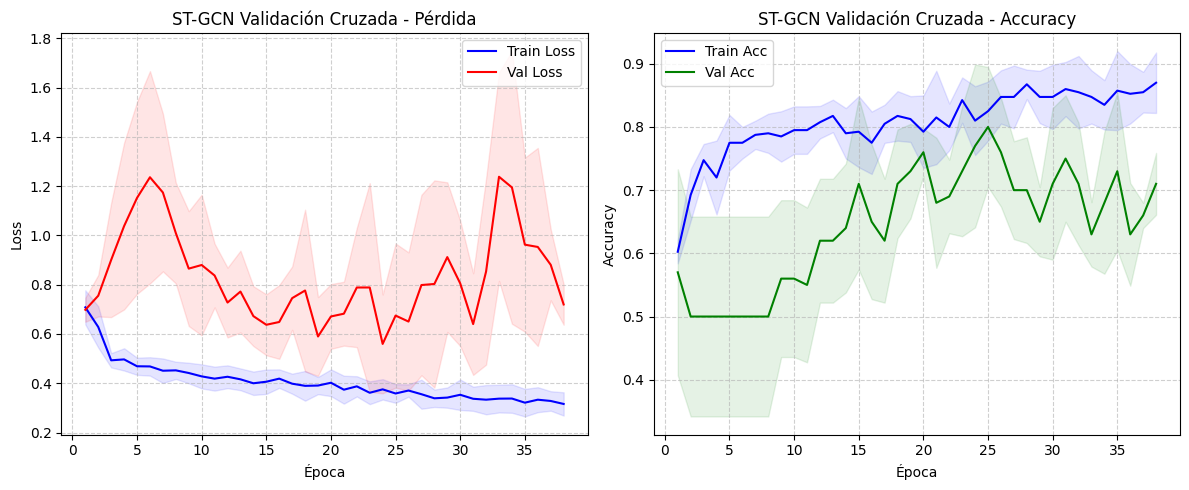

In [47]:
# Definimos los parámetros del modelo en un diccionario
# Esto es necesario para pasar los argumentos al constructor de la clase del modelo
model_params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS_K1  
}


# Ejecutamos el experimento
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=STGCN_Model, # Pasamos la CLASE, no una instancia
    model_params=model_params,          # Argumentos para instanciarla
    X_full=X_tensor,                     
    y_full=y_tensor,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,                        # Early Stopping activado
    device=device
)

# 4. Graficamos
plot_kfold_history_pytorch(histories, title="ST-GCN Validación Cruzada")

#### Evaluación con Bootstrapping

In [48]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import numpy as np

def calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=1000, alpha=0.95):
    """
    Calcula el intervalo de confianza usando Bootstrapping sobre las predicciones.
    """
    stats = []
    
    # 1. Bucle de simulaciones (1000 veces)
    for i in range(n_iterations):
        # Generamos índices aleatorios con reemplazo
        # (Simula meter la mano en la bolsa y sacar bolas repetidas)
        indices = resample(range(len(y_pred)), replace=True)
        
        # Creamos el "dataset virtual"
        sample_pred = y_pred[indices]
        sample_true = y_true[indices]
        
        # Calculamos el accuracy de esta simulación
        score = accuracy_score(sample_true, sample_pred)
        stats.append(score)
    
    # 2. Ordenamos los 1000 resultados de menor a mayor
    stats = np.sort(stats)
    
    # 3. Calculamos los límites (cortamos las colas)
    lower_percentile = ((1.0 - alpha) / 2.0) * 100
    upper_percentile = (alpha + ((1.0 - alpha) / 2.0)) * 100
    
    lower = np.percentile(stats, lower_percentile)
    upper = np.percentile(stats, upper_percentile)
    
    print(f"Accuracy Promedio (Bootstrap): {np.mean(stats):.4f}")
    print(f"Intervalo de Confianza {int(alpha*100)}%: [{lower:.4f}, {upper:.4f}]")
    
    return lower, upper, stats

Accuracy Promedio (Bootstrap): 0.8287
Intervalo de Confianza 95%: [0.7500, 0.9100]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


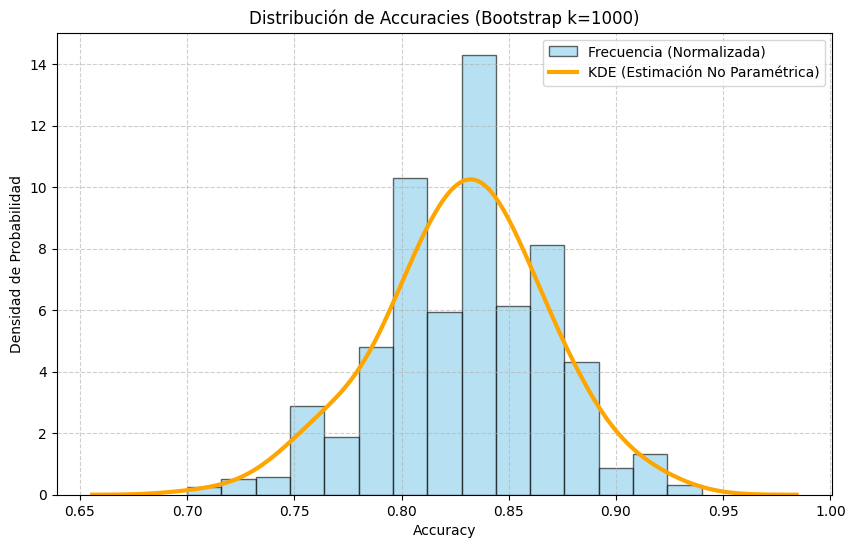

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graficamos el histograma de accuracies bootstrap
n_iterations = 1000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=15, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)', bw_adjust=1.5)

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [50]:
# Guardamos el array en disco para análisis posterior
np.save('./results/bootstrap_accuracies_exp_st_gcn_01.npy', stats)

### EXP-ST-GCN-02

In [51]:
%pwd

'/kaggle/working/push-up-video-classification'

In [52]:
import torch
import numpy as np

X_correct_mirrored = np.load('./Data/Processed/mirrored_correct_push_ups_landmarks.npy')
X_incorrect_mirrored = np.load('./Data/Processed/mirrored_wrong_push_ups_landmarks.npy')

X_mirrored = np.vstack((X_correct_mirrored, X_incorrect_mirrored))
y_mirrored = np.array([1]*X_correct_mirrored.shape[0] + [0]*X_incorrect_mirrored.shape[0])  

# Convertir a tensores de PyTorch
X_tensor_mirrored = torch.tensor(X_mirrored, dtype=torch.float32)
y_tensor_mirrored = torch.tensor(y_mirrored, dtype=torch.long) # Las etiquetas de clasificación deben ser LONG

input_channels = X_tensor_mirrored.shape[2]  # Número de características por frame (coordenadas x,y de 33 puntos)
seq_len = X_tensor_mirrored.shape[1]         # Número de frames por secuencia (video)

# Obtener el número de muestras (N)
n_samples_mirrored = X_tensor_mirrored.shape[0]

# Crea un array con los índices de los grupos (videos originales)
mirrored_index = np.arange(n_samples_mirrored)

In [53]:
# Creamos un array con los índices de los grupos (videos originales)
groups = np.concatenate([original_index, mirrored_index])

# Concatenamos los datos originales y aumentados
X_tensor_concat = torch.cat((X_tensor, X_tensor_mirrored), dim=0)
y_tensor_concat = torch.cat((y_tensor, y_tensor_mirrored), dim=0)

groups

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99,  0,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86,
       87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

** Iniciando K-Fold Modular (5 splits) en cuda...

🔄 Pliegue 1/5
    -> Early stopping en época 50
    + Fin Fold 1. Mejor Acc Val: 0.9000

🔄 Pliegue 2/5
    -> Early stopping en época 69
    + Fin Fold 2. Mejor Acc Val: 0.9500

🔄 Pliegue 3/5
    -> Early stopping en época 48
    + Fin Fold 3. Mejor Acc Val: 0.8250

🔄 Pliegue 4/5
    -> Early stopping en época 51
    + Fin Fold 4. Mejor Acc Val: 0.7250

🔄 Pliegue 5/5
    -> Early stopping en época 56
    + Fin Fold 5. Mejor Acc Val: 0.9250
📊 Resultados K-Fold:
| Accuracy Medio: 0.8650 (+/- 0.0815)
Graficando las primeras 48 épocas comunes...


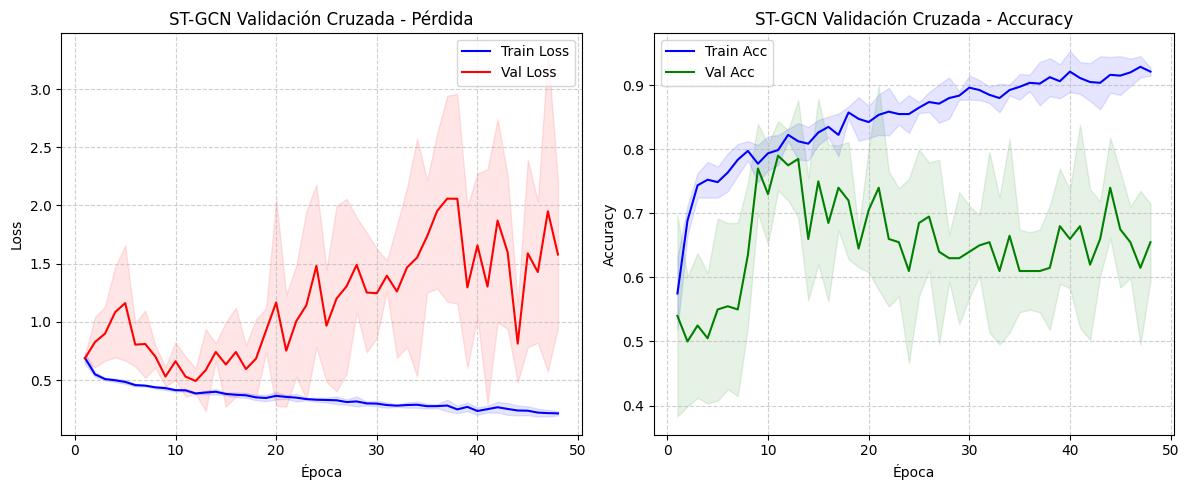

In [59]:
# Definimos los parámetros del modelo en un diccionario
# Esto es necesario para pasar los argumentos al constructor de la clase del modelo
model_params = {
    'num_classes': 2,
    'A_partitions': A_PARTITIONS_K1  
}


# Ejecutamos el experimento
mean_acc, std_acc, histories, y_true, y_pred = run_kfold_experiment_pytorch(
    model_class=STGCN_Model, # Pasamos la CLASE, no una instancia
    model_params=model_params,          # Argumentos para instanciarla
    X_full=X_tensor_concat,                     
    y_full=y_tensor_concat,
    epochs=100,
    batch_size=32,
    n_splits=5,
    patience=35,                        # Early Stopping activado
    device=device
)

# 4. Graficamos
plot_kfold_history_pytorch(histories, title="ST-GCN Validación Cruzada")

#### Evaluación con Bootstrapping

Accuracy Promedio (Bootstrap): 0.8654
Intervalo de Confianza 95%: [0.8150, 0.9150]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


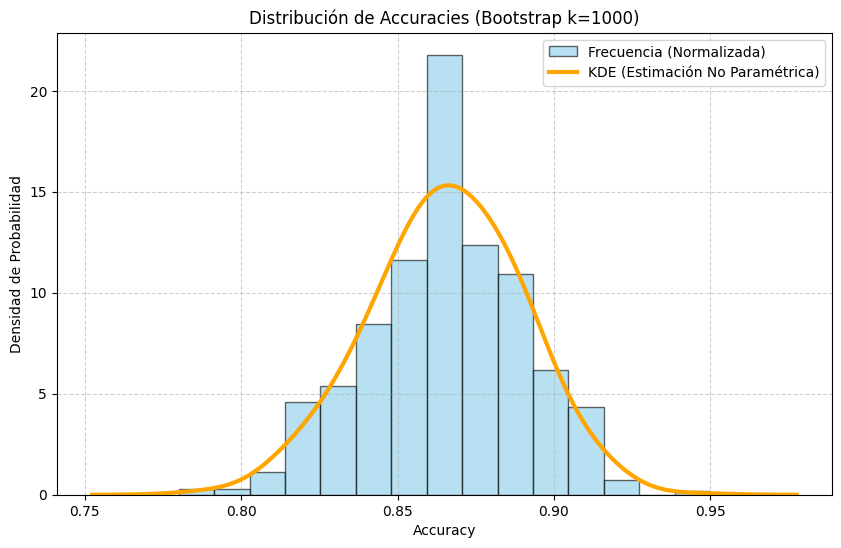

In [60]:
# Graficamos el histograma de accuracies bootstrap
n_iterations = 1000
_, _, stats = calcular_bootstrap_intervalo(y_true, y_pred, n_iterations=n_iterations, alpha=0.95)


plt.figure(figsize=(10, 6))

# 1. Histograma NORMALIZADO (density=True)
plt.hist(stats, bins=15, color='skyblue', edgecolor='black', 
         density=True, alpha=0.6, label='Frecuencia (Normalizada)')

# 2. Gráfico KDE (Estimación de Densidad de Kernel)
sns.kdeplot(stats, color='orange', lw=3, label='KDE (Estimación No Paramétrica)', bw_adjust=1.5)

plt.title(f'Distribución de Accuracies (Bootstrap k={n_iterations})')
plt.xlabel('Accuracy')
plt.ylabel('Densidad de Probabilidad') # Ojo: Ya no es "Frecuencia" absoluta
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [61]:
# Guardamos el array en disco para análisis posterior
np.save('./results/bootstrap_accuracies_exp_st_gcn_02.npy', stats)